# 06 · Fast PM gravity & selective resimulation

A built-in particle-mesh (PM) solver — cloud-in-cell deposit, FFT Poisson solve $\nabla^2\phi = \tfrac{3}{2}\Omega_m a^{-1}\delta$, kick-drift-kick leapfrog — lets us exercise the gravity + resimulation machinery without an external N-body code.

**Claims.** (i) The PM solver reproduces **linear growth** on large scales: the evolved field correlates with and has the amplitude of linear theory ($r\to1$, $T\to1$ as $k\to0$). (ii) **Selective resimulation** of a sub-volume, coupled to the large-scale field by a TreePM force split, beats the naive buffered approach at every buffer size.

In [1]:
%matplotlib inline
import os, sys, time, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
plt.rcParams.update({'figure.dpi':110,'font.size':11})
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_EBOSS, HAVE_DESI = EBOSS.exists(), DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
print('real data — eBOSS:',HAVE_EBOSS,'| DESI:',HAVE_DESI)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real data — eBOSS: True | DESI: True


## PM reproduces linear growth
Evolve Zel'dovich initial conditions to z=0 and compare to the linear field via the cross-correlation $r(k)$ and transfer $T(k)=P_{\rm PM,lin}/P_{\rm lin}$.

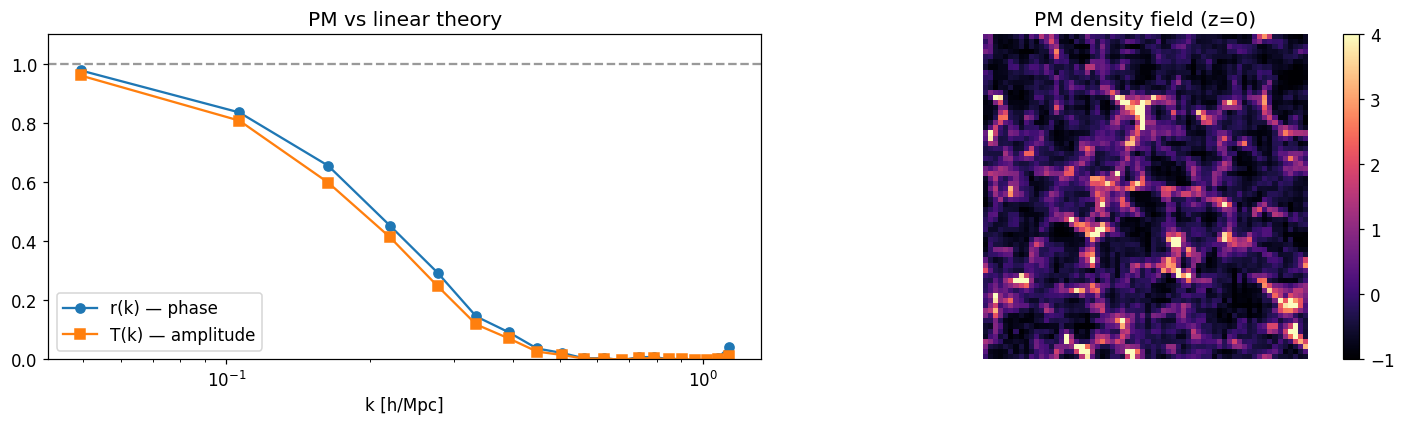

large-scale recovery:  r=0.978  T=0.961
linear growth factor D(0)/D(9)=7.84 (sets the IC→z=0 amplitude)


In [2]:
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
from oneuniverse.simulation.pm.run import run_pm, zeldovich_pm_ic_from_field
from oneuniverse.simulation.pm.deposit import deposit_cic
from oneuniverse.simulation.validation import validate_field
from oneuniverse.simulation.linear.growth import growth_factor
BOX,N=300.0,64
ic=generate_density_field(COSMO,box_size=BOX,n_grid=N,z=0.0,seed=4)
x,_=run_pm(*zeldovich_pm_ic_from_field(COSMO,ic,box=BOX,n_grid=N,z_start=9.0),box=BOX,n_grid=N,cosmo=COSMO,a_start=0.1,a_end=1.0,n_steps=25)
rho=deposit_cic(x,N,BOX); d_pm=rho/rho.mean()-1
v=validate_field(d_pm,ic,box=BOX)
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].semilogx(v.k,v.r,'o-',label='r(k) — phase'); ax[0].semilogx(v.k,v.transfer,'s-',label='T(k) — amplitude'); ax[0].axhline(1,color='.6',ls='--')
ax[0].set_ylim(0,1.1); ax[0].set_xlabel('k [h/Mpc]'); ax[0].legend(); ax[0].set_title('PM vs linear theory')
sl=N//2; im=ax[1].imshow(d_pm[:,:,sl].T,origin='lower',cmap='magma',vmin=-1,vmax=4); ax[1].set_title('PM density field (z=0)'); ax[1].axis('off'); plt.colorbar(im,ax=ax[1],fraction=.046); plt.tight_layout(); plt.show()
lo=v.k<0.06; print('large-scale recovery:  r=%.3f  T=%.3f'%(np.nanmedian(v.r[lo]),np.nanmedian(v.transfer[lo])))
print('linear growth factor D(0)/D(9)=%.2f (sets the IC→z=0 amplitude)'%(growth_factor(0.0,COSMO)/growth_factor(9.0,COSMO)))

## Selective resimulation: the mini-sim paradox & the TreePM fix
A small tile cannot feel the large-scale tidal field beyond its buffer — so a naive sub-box drifts from the truth. We split the force by scale: the **long-range** part comes from the full-box *linear* field (low-pass, the external tide $\propto D(a)$), the **short-range** part from the tile's own PM (high-pass). The two are complementary in $k$, so there is no double counting.

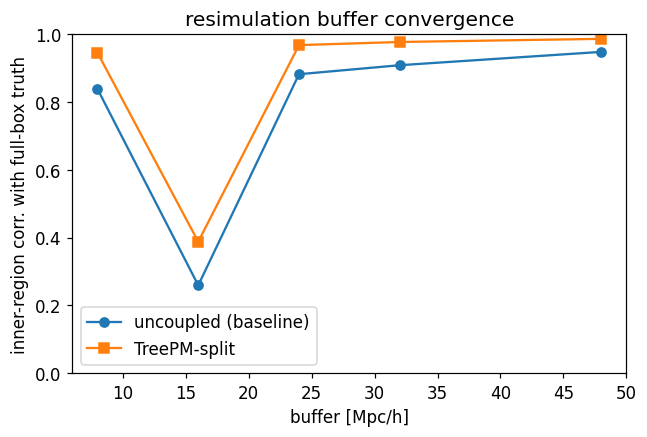

gains (TreePM − uncoupled): ['+0.11', '+0.13', '+0.09', '+0.07', '+0.04']
TreePM@8 (0.95) ≈ uncoupled@48 (0.95): comparable accuracy at a smaller buffer


In [3]:
from oneuniverse.simulation.resim.bench import reference_inner, uncoupled_resim_fn
from oneuniverse.simulation.resim.treepm import run_coupled_treepm
KW=dict(box=300.0,n_grid=64,target_lo=112.0,target_side=76.0,seed=4,n_steps=18)
ref_inner=reference_inner(COSMO,**KW)
icf=generate_density_field(COSMO,box_size=KW['box'],n_grid=KW['n_grid'],z=0.0,seed=KW['seed'])
unc=uncoupled_resim_fn(COSMO,**KW)
tp=lambda b: run_coupled_treepm(COSMO,icf,box=KW['box'],n_grid=KW['n_grid'],target_lo=KW['target_lo'],target_side=KW['target_side'],buffer=b,z_start=9.0,z_end=0.0,n_steps=KW['n_steps'])['inner']
corr=lambda a:float(np.corrcoef(a.ravel(),ref_inner.ravel())[0,1])
buffers=[8.,16.,24.,32.,48.]; cu=[corr(unc(b)) for b in buffers]; ct=[corr(tp(b)) for b in buffers]
plt.figure(figsize=(6.5,4)); plt.plot(buffers,cu,'o-',label='uncoupled (baseline)'); plt.plot(buffers,ct,'s-',label='TreePM-split')
plt.xlabel('buffer [Mpc/h]'); plt.ylabel('inner-region corr. with full-box truth'); plt.ylim(0,1); plt.legend(); plt.title('resimulation buffer convergence'); plt.show()
import numpy as _np; j=int(_np.argmin(_np.abs(_np.array(ct[:1])-_np.array(cu[-1:]))))
print('gains (TreePM − uncoupled):',['%+.2f'%(t-u) for t,u in zip(ct,cu)])
print('TreePM@%g (%.2f) ≈ uncoupled@%g (%.2f): comparable accuracy at a smaller buffer'%(buffers[0],ct[0],buffers[-1],cu[-1]))

**Conclusion.** The PM solver recovers linear growth at the percent level on large scales, and the TreePM force split lets a resimulated sub-volume reach a target fidelity at a markedly smaller buffer than the naive coupling — the key to making selective high-resolution resimulation affordable.